In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Load the cleaned dataset

processed_file = Path("../data/processed/telco_customer_churn_clean.csv")

df = pd.read_csv(processed_file)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Dataset loaded successfully!
Rows: 7,043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Basic verification

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Missing values:
0

Duplicate rows:
0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [4]:
# Baseline customer metrics

total_customers = len(df)

churned_customers = (df["Churn"] == "Yes").sum()

churn_rate = churned_customers / total_customers

avg_monthly_charge = df["MonthlyCharges"].mean()

avg_tenure = df["tenure"].mean()

total_monthly_revenue = df["MonthlyCharges"].sum()

print(f"Total customers: {total_customers:,}")
print(f"Churned customers: {churned_customers:,}")
print(f"Churn rate: {churn_rate:.2%}")
print(f"Average monthly charge: ${avg_monthly_charge:.2f}")
print(f"Average tenure: {avg_tenure:.2f} months")
print(f"Total monthly charges: ${total_monthly_revenue:,.2f}")

Total customers: 7,043
Churned customers: 1,869
Churn rate: 26.54%
Average monthly charge: $64.76
Average tenure: 32.37 months
Total monthly charges: $456,116.60


In [5]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    "Customers": churn_counts,
    "Percentage": churn_percent.round(2)
})

churn_summary

,Customers,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


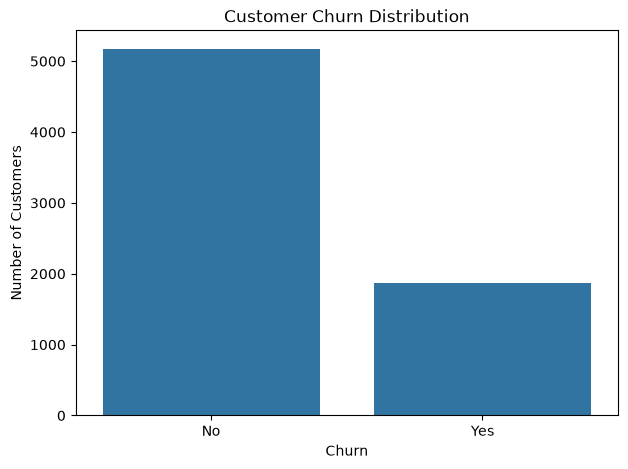

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
# Tenure summary

print("Tenure statistics:")
print(df["tenure"].describe())

Tenure statistics:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


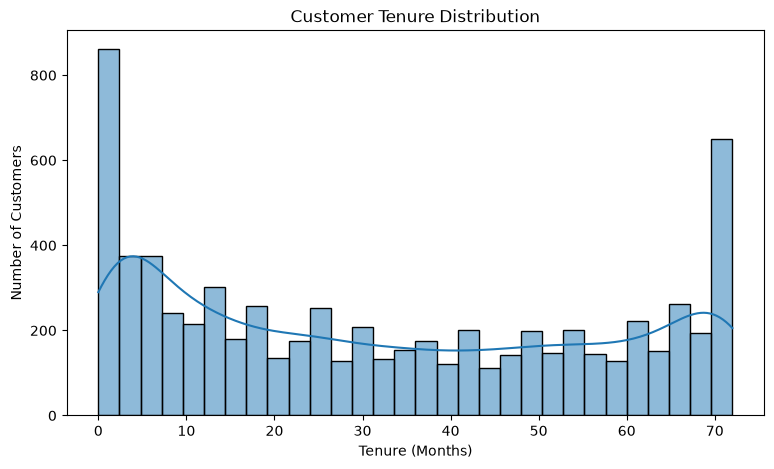

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
tenure_by_churn = (
    df.groupby("Churn")["tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

tenure_by_churn

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


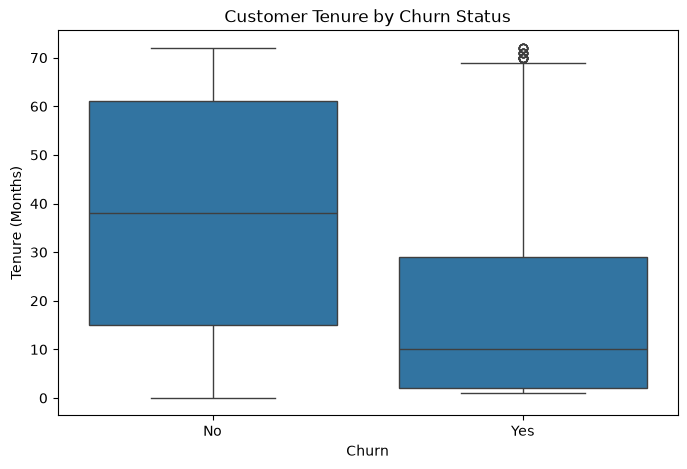

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [11]:
monthly_charges_summary = df["MonthlyCharges"].describe().round(2)

monthly_charges_summary

count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: MonthlyCharges, dtype: float64

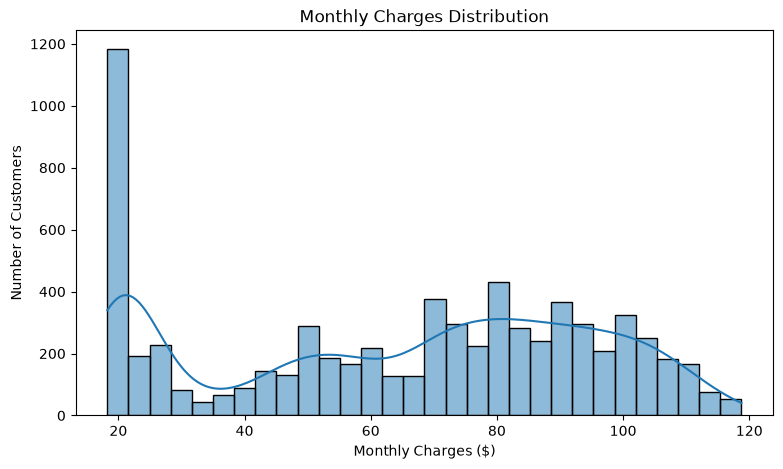

In [12]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
monthly_charges_by_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

monthly_charges_by_churn

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


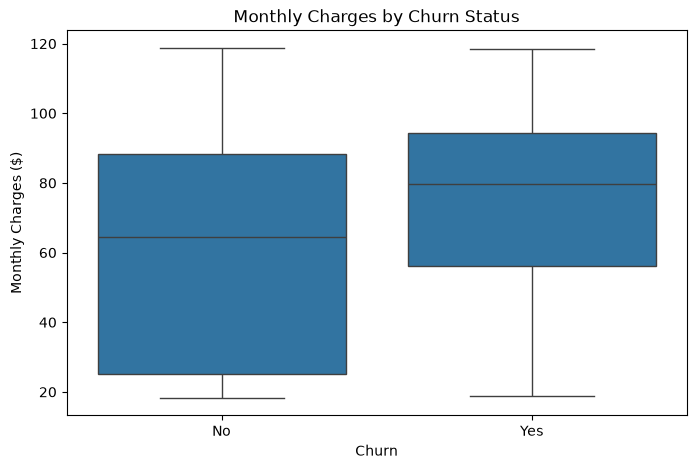

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

In [15]:
total_charges_summary = df["TotalCharges"].describe().round(2)

total_charges_summary

count    7043.00
mean     2279.73
std      2266.79
min         0.00
25%       398.55
50%      1394.55
75%      3786.60
max      8684.80
Name: TotalCharges, dtype: float64

In [16]:
total_charges_by_churn = (
    df.groupby("Churn")["TotalCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

total_charges_by_churn

,count,mean,median,min,max
Churn,,,,,
No,5174,2549.91,1679.52,0.00,8672.45
Yes,1869,1531.80,703.55,18.85,8684.80


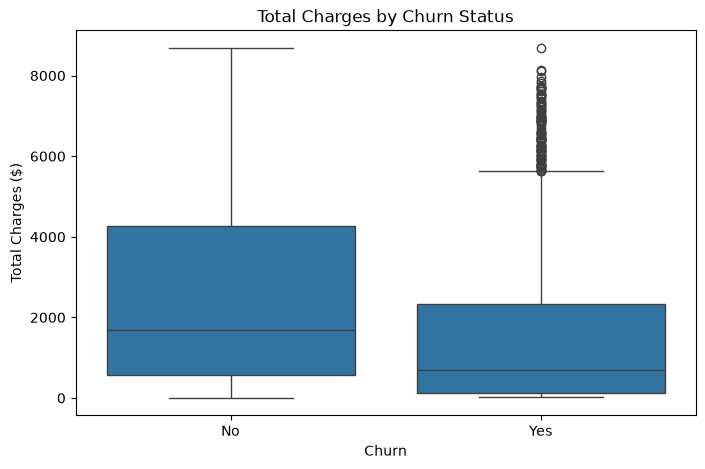

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges ($)")

plt.show()

In [18]:
contract_counts = df["Contract"].value_counts()

contract_counts

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [20]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

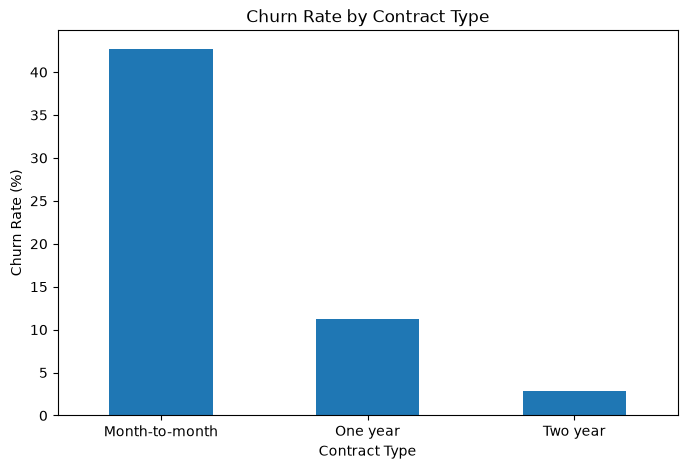

In [21]:
plt.figure(figsize=(8, 5))

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [22]:
internet_counts = df["InternetService"].value_counts()

internet_counts

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [23]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

internet_churn

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

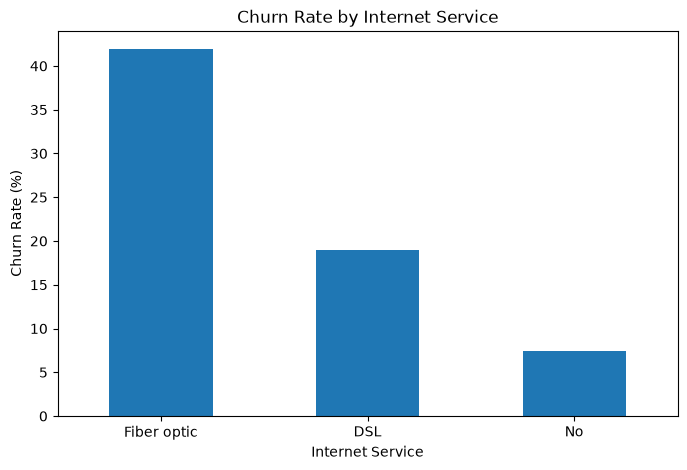

In [24]:
plt.figure(figsize=(8, 5))

internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [25]:
payment_counts = df["PaymentMethod"].value_counts()

payment_counts

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [26]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

In [27]:
security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

security_churn

OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

In [28]:
support_churn = (
    df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

support_churn

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

In [29]:
eda_summary = pd.DataFrame({
    "Dimension": [
        "Contract",
        "Contract",
        "Contract",
        "Internet Service",
        "Internet Service",
        "Internet Service",
        "Payment Method",
        "Payment Method",
        "Payment Method",
        "Payment Method",
        "Online Security",
        "Online Security",
        "Tech Support",
        "Tech Support"
    ],
    "Segment": [
        "Month-to-month",
        "One year",
        "Two year",
        "Fiber optic",
        "DSL",
        "No internet service",
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)",
        "No",
        "Yes",
        "No",
        "Yes"
    ],
    "Observed_Churn_Rate": [
        42.71,
        11.27,
        2.83,
        41.89,
        18.96,
        7.40,
        45.29,
        19.11,
        16.71,
        15.24,
        41.77,
        14.61,
        41.64,
        15.17
    ]
})

eda_summary

,Dimension,Segment,Observed_Churn_Rate
0,Contract,Month-to-month,42.71
1,Contract,One year,11.27
2,Contract,Two year,2.83
3,Internet Service,Fiber optic,41.89
4,Internet Service,DSL,18.96
5,Internet Service,No internet service,7.40
6,Payment Method,Electronic check,45.29
7,Payment Method,Mailed check,19.11
8,Payment Method,Bank transfer (automatic),16.71
9,Payment Method,Credit card (automatic),15.24


In [30]:
gender_churn = (
    df.groupby("gender")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

gender_churn

gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

In [31]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

senior_churn.index = ["Non-Senior Citizen", "Senior Citizen"]

senior_churn

Non-Senior Citizen    23.61
Senior Citizen        41.68
Name: Churn, dtype: float64

In [32]:
partner_churn = (
    df.groupby("Partner")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

partner_churn

Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

In [33]:
dependents_churn = (
    df.groupby("Dependents")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

dependents_churn

Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

In [34]:
contract_internet_churn = (
    df.groupby(["Contract", "InternetService"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .unstack()
)

contract_internet_churn

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22,54.61,18.89
One year,9.30,19.29,2.47
Two year,1.91,7.23,0.78


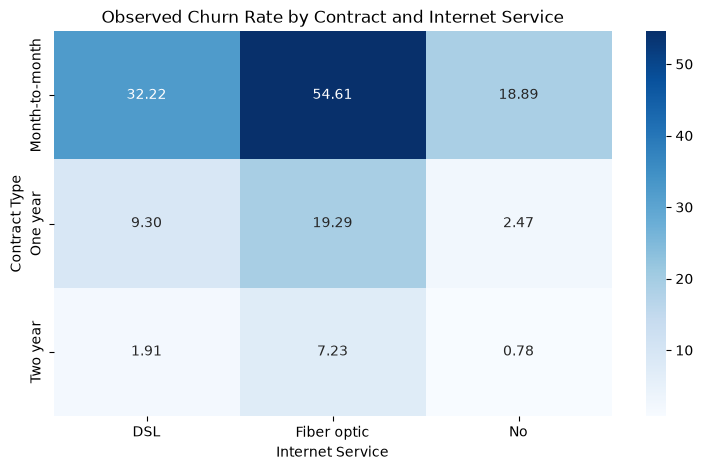

In [35]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    contract_internet_churn,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Observed Churn Rate by Contract and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract Type")

plt.show()

In [36]:
contract_payment_churn = (
    df.groupby(["Contract", "PaymentMethod"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .unstack()
)

contract_payment_churn

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.13,32.78,53.73,31.58
One year,9.72,10.30,18.44,6.82
Two year,3.37,2.24,7.74,0.79


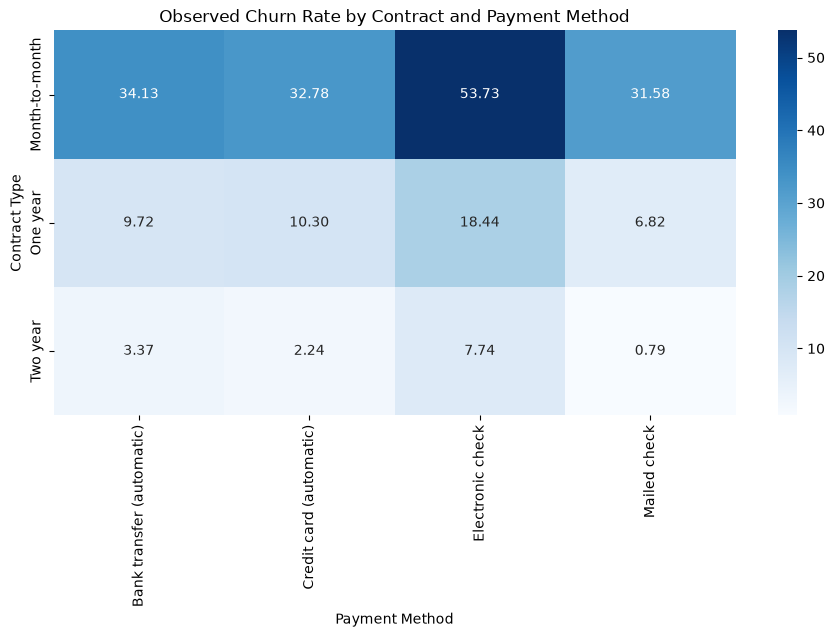

In [37]:
plt.figure(figsize=(11, 5))

sns.heatmap(
    contract_payment_churn,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Observed Churn Rate by Contract and Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Contract Type")

plt.show()

In [38]:
from scipy.stats import chi2_contingency

contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(contract_table)

print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 1184.6
p-value: 5.863038300673391e-258
Degrees of freedom: 2


In [39]:
internet_table = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    internet_table
)

print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 732.31
p-value: 9.571788222840544e-160
Degrees of freedom: 2


In [40]:
payment_table = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    payment_table
)

print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 648.14
p-value: 3.6823546520097993e-140
Degrees of freedom: 3


# EDA Conclusions

## Overall Customer Base

The dataset contains 7,043 customers, with an overall observed churn rate of approximately 26.5%.

The customer population shows substantial variation in tenure, monthly charges, contract type, internet service, payment method, and customer support services.

## Key Observed Churn Patterns

### 1. Tenure

Churned customers have substantially shorter observed tenure than customers who did not churn.

- Average tenure of retained customers: 37.57 months
- Average tenure of churned customers: 17.98 months
- Median tenure of retained customers: 38 months
- Median tenure of churned customers: 10 months

This indicates that early-tenure customers are an important population for further churn analysis.

### 2. Monthly Charges

Churned customers have higher monthly charges on average.

- Retained customers: $61.27 average monthly charge
- Churned customers: $74.44 average monthly charge

This suggests that monthly charges may be an important risk-related feature, although the relationship may overlap with contract type, internet service, and other customer characteristics.

### 3. Contract Type

Contract type shows one of the strongest observed differences in churn.

- Month-to-month: 42.71%
- One year: 11.27%
- Two year: 2.83%

A Chi-square test also found a statistically significant association between contract type and churn.

### 4. Internet Service

Observed churn also varies substantially by internet service.

- Fiber optic: 41.89%
- DSL: 18.96%
- No internet service: 7.40%

Internet service and churn were statistically associated in the Chi-square analysis.

### 5. Payment Method

Electronic check customers have the highest observed churn rate among payment methods.

- Electronic check: 45.29%
- Mailed check: 19.11%
- Bank transfer (automatic): 16.71%
- Credit card (automatic): 15.24%

Payment method and churn were also statistically associated.

### 6. Support Services

Customers without Online Security or Tech Support have substantially higher observed churn rates than customers with these services.

These relationships should be treated as associations rather than causal effects.

### 7. Customer Demographics

Gender shows little difference in observed churn:

- Female: 26.92%
- Male: 26.16%

Other demographic variables show larger differences, including Senior Citizen status, Partner status, and Dependents.

### 8. Interaction Analysis

The combination of customer characteristics reveals stronger risk segments than individual variables alone.

Examples include:

- Month-to-month + Fiber optic: 54.61% observed churn
- Month-to-month + Electronic check: 53.73% observed churn

These results demonstrate why multi-variable analysis is important for customer risk segmentation.

## Statistical Analysis

Chi-square tests found statistically significant associations between churn and:

- Contract type
- Internet service
- Payment method

Statistical significance indicates evidence of association within this dataset; it does not establish causation.

## EDA Limitations

This dataset is a customer-level snapshot rather than a true longitudinal history.

Therefore:

- Churn timing cannot be analyzed directly.
- Monthly customer behavior is not available.
- Observed relationships should not be interpreted as causal.
- Total Charges is strongly influenced by customer tenure.
- Segment-level associations may reflect overlapping customer characteristics.

These limitations motivate the next stage of the project, where additional features and a synthetic longitudinal customer layer will be developed for deeper retention analysis.

## Business Questions for the Next Stage

The EDA suggests several questions for further analysis:

1. Which customers are most likely to churn?
2. Which high-value customers are at risk?
3. What customer characteristics contribute most to predicted churn risk?
4. How should customer lifetime value influence retention prioritization?
5. Which customers are economically worth targeting with a retention intervention?

The next stage will address these questions through feature engineering, customer value analysis, churn prediction, and cost-sensitive retention strategy.